Logs   
- [2026/03/17]    
  Testing matplotlib

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import program.luminance as luminance
import program.color as color

from program.picture import Picture
from PIL import Image

In [7]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [8]:
mpl.__version__

'3.7.3'

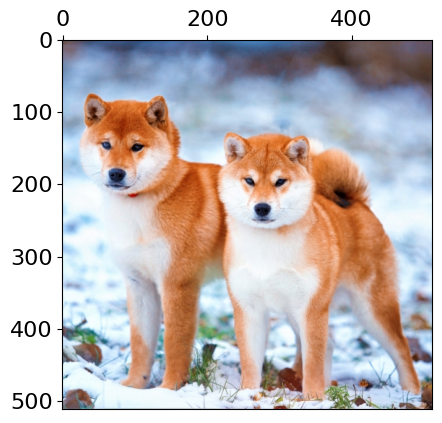

In [19]:
# img_rgb = np.array([
#   [[255,   0,   0],
#    [  0, 255,   0],
#    [  0,   0, 255]],

#   [[  0, 255,   0],
#    [  0,   0, 255],
#    [255,   0,   0]]
# ], dtype=np.uint8)


_DEFAULT_WIDTH = 512
_DEFAULT_HEIGHT = 512

image_path = "./data/japan-shiba-inu-512px.jpg"
# image_path = "./data/mandrill.jpg"
image = Image.open(image_path)
img_rgb = np.array(image)


fig, ax = plt.subplots()

imshow_handler = ax.imshow(img_rgb)

ax.set_aspect("equal")
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show(fig)

Get the size of the image

In [11]:
fig.get_axes()[0].get_children()[0].get_size()

(512, 512)

Get the pixel color at specific coordinate

In [12]:
a = fig.get_axes()[0].get_children()[0].get_array()
row_color = a[0, 3].data
display(row_color)

def get_color(c1, c2, c3):
  print(c1, c2, c3)

get_color(*row_color)

array([98, 77, 72], dtype=uint8)

98 77 72


Set the pixel color at specific point

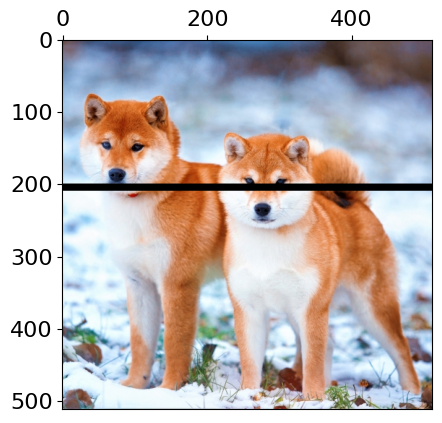

In [45]:
im_data = fig.get_axes()[0].get_children()[0].get_array()
im_data[200:210, :, :] = [0, 0, 0]

fig

test `Picture`

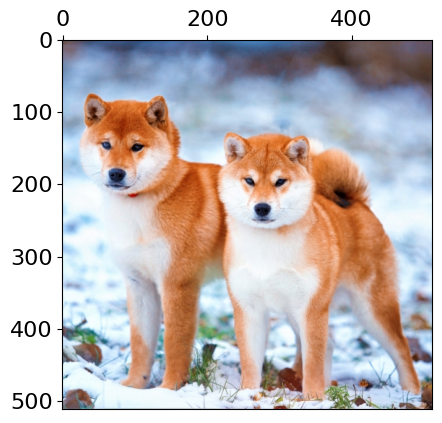

In [28]:
# picture = Picture()
picture = Picture("./data/japan-shiba-inu-512px.jpg")
# picture = Picture("./data/mandrill.jpg")
picture.draw()
plt.show(picture._fig)

In [15]:
picture._surface.shape

(512, 512, 3)

Test grayscale

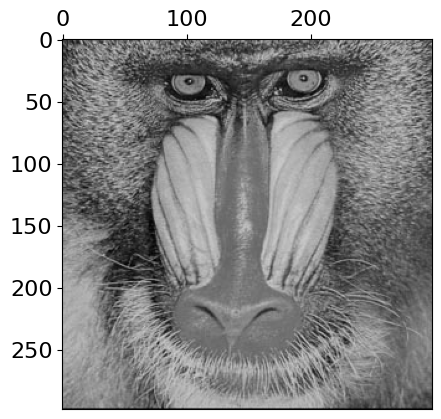

In [48]:
pic = Picture("./data/mandrill.jpg")

# data_color = pic._surface[0, 0, :]
# color.Color(*data_color)
for col in range(pic.width()):
  for row in range(pic.height()):
    pixel = pic.get(col, row)
    # print(pixel, end=" ")
    gray = luminance.to_gray(pixel)
    # print(gray, end=" ")
    pic.set(col, row, gray)
  # print()

pic.draw()

plt.show(pic._fig)

Test image scaling

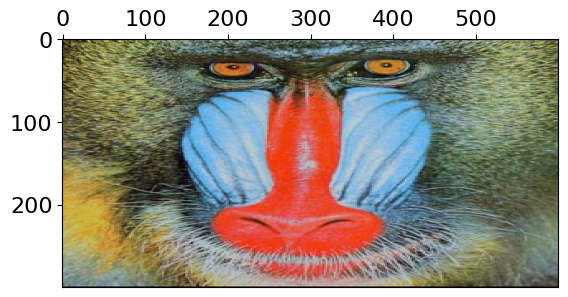

In [81]:
source = Picture("./data/mandrill.jpg")
w_t = 600
h_t = 300

target = Picture(w_t, h_t)
# print(target.width(), target.height())
# print(target._surface[3, 3, :])

for col_t in range(w_t):
  for row_t in range(h_t):
    col_s = col_t * source.width() // w_t
    row_s = row_t * source.height() // h_t
    # print(col_t, row_t, col_s, row_s)
    # print(source.get(col_s, row_s), end=" ")
    target.set(col_t, row_t, source.get(col_s, row_s))
  # print()

# # source._surface[0, 0, :]
# # target._surface[3, 3, :]

target.draw()
plt.show(target._fig)

Get data from `ax.plot`

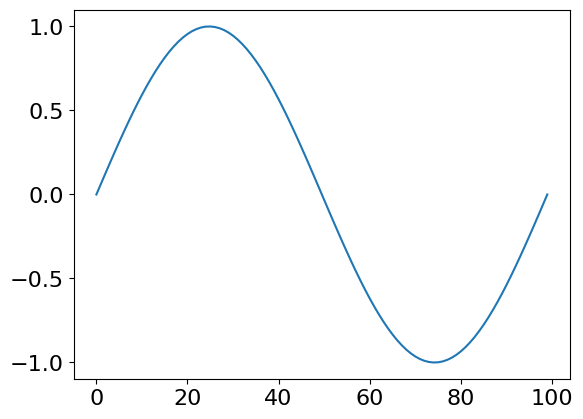

In [16]:
fig, ax = plt.subplots()

line_handler = ax.plot(np.sin(np.linspace(0, 2*np.pi, 100)))

plt.show(fig)

In [17]:
line_handler[0].get_xdata()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
       52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
       65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77.,
       78., 79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90.,
       91., 92., 93., 94., 95., 96., 97., 98., 99.])